# CMSE 202 - Pneumonia Classification Using Traditional Machine Learning

## SVM - C value and Kernal comparison

Imports and deleting .DS_Store files for macOS users

In [28]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.io import imread
from skimage.transform import resize

from sklearn.datasets import load_files
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    ConfusionMatrixDisplay,
)

from ipywidgets import interact


#Cleans up macOS .DS_Store files that can break directory loops
for root, dirs, files in os.walk(".."):
    for file in files:
        if file == ".DS_Store":
            os.remove(os.path.join(root, file))

### Loading in data and organizing it

In [12]:
# Setup the directory paths
data_folder = os.path.join("..", "..", "data", "processed", "binary")
train_folder = os.path.join(data_folder, "train")
test_folder = os.path.join(data_folder, "test")
model_output_dir = os.path.join("..", "..", "models")

print(f"Train folder: {train_folder}")
print(f"Test folder: {test_folder}")

Train folder: ../../data/processed/binary/train
Test folder: ../../data/processed/binary/test


In [14]:
# Load in the images
train_dataset = load_files(train_folder, load_content=False)
test_dataset = load_files(test_folder, load_content=False)

X_train = [] 
X_test = []
y_train = train_dataset.target
y_test = test_dataset.target
categories = train_dataset.target_names

image_size = 128
grayscale = True

# Resize/grayscale the images and add them to respective arrays
for filename in train_dataset.filenames:
    try:
        img = img = Image.open(filename).convert("L" if grayscale else "RGB").resize((image_size, image_size))
        img_array = np.array(img).flatten()
        X_train.append(img_array)
    except Exception as e:
        print(f"Error loading image: {filename} - {e}")
        
for filename in test_dataset.filenames:
    try:
        img = img = Image.open(filename).convert("L" if grayscale else "RGB").resize((image_size, image_size))
        img_array = np.array(img).flatten()
        X_test.append(img_array)
    except Exception as e:
        print(f"Error loading image: {filename} - {e}")
        
X_train = np.array(X_train)
X_test = np.array(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (2000, 16384), Test shape: (500, 16384)


In [16]:

# View the train dataset
def browse_images(images, labels, filenames, categories):
    n = len(images)
    def view_image(i):
        plt.imshow(images[i], cmap=plt.cm.gray, interpolation='nearest')
        plt.title(f'{categories[labels[i]]} ({filenames[i].split('\\')[-1]})')
        plt.axis('off')
        plt.show()
    interact(view_image, i=(0,n-1))
    
browse_images(X_train.reshape([X_train.shape[0], image_size, image_size]), y_train, train_dataset.filenames, categories)

interactive(children=(IntSlider(value=999, description='i', max=1999), Output()), _dom_classes=('widget-intera…

In [18]:
# PCA to preserve 95% variance in the data
variance = 0.95

pca = PCA(n_components=variance)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]} capturing {variance*100}% variance")


PCA reduced features from 16384 to 329 capturing 95.0% variance


## Create data to graph

In [24]:
def graphs(train_vectors, train_labels, test_vectors, test_labels):
    """
    Stores precision and accuracy scores for the three different kernal types, for different c values

    Parameters:
    - train_vectors: vectors which the model is to be trained with
    - train_lables: lables which the model is to be trained with
    - test_vectors: vectors which the model is to be tested on
    - test_lables: lables which the model is to be tested on

    Returns:
    - results['linear']: Precision and accuray results for the linear kernal, at different C values
    - results['rbf']: Precision and accuray results for the rbf kernal, at different C values
    - results['poly']: Precision and accuray results for the poly kernal, at different C values
    """
    
    start = time.time()
    
    c_values = [0.01, 0.1, 1, 10, 100]
    #create empty lists to store accuracy and precision values
    linear = []
    rbf = []
    poly = []
    #Define the kernal names that will be used in the loop
    kernels = ['linear', 'rbf', 'poly']
    #Create dictionary to store those lists
    results = {'linear': linear, 'rbf': rbf, 'poly': poly}

    for kernel in kernels:
        for c in c_values:
            #Run the model for every C value in the list above
            clf = OneVsRestClassifier(SVC(kernel=kernel, C=c, class_weight='balanced'))
            clf.fit(train_vectors, train_labels)
            pred = clf.predict(test_vectors)
            
            # Assistance with appending precision and accuracy scores provided by ChatGPT (OpenAI, 2025).
            per_class_prec = precision_score(test_labels, pred, average=None, zero_division=0)
            acc = accuracy_score(test_labels, pred)

            #Append the results into the lists
            row = [per_class_prec[0], per_class_prec[1], acc]
            results[kernel].append(row)

    end = time.time()
    print("Total runtime:", round(end - start, 2), "seconds")
    
    return results['linear'], results['rbf'], results['poly']

    
linear, rbf, poly = graphs(X_train_pca, y_train, X_test_pca, y_test)

Total runtime: 6.2 seconds


## Graph Models

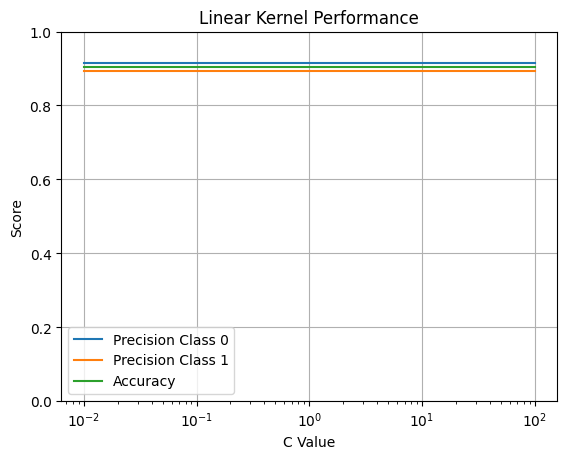

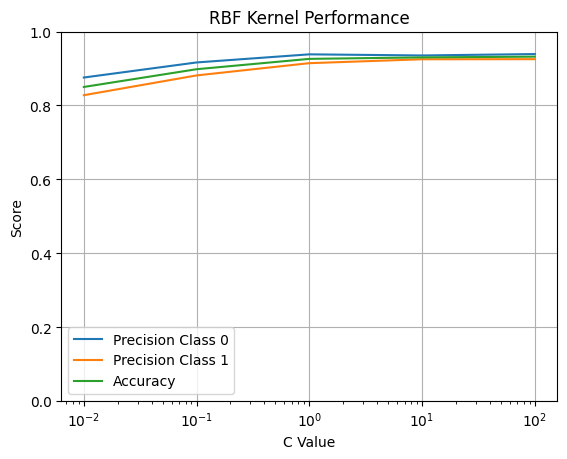

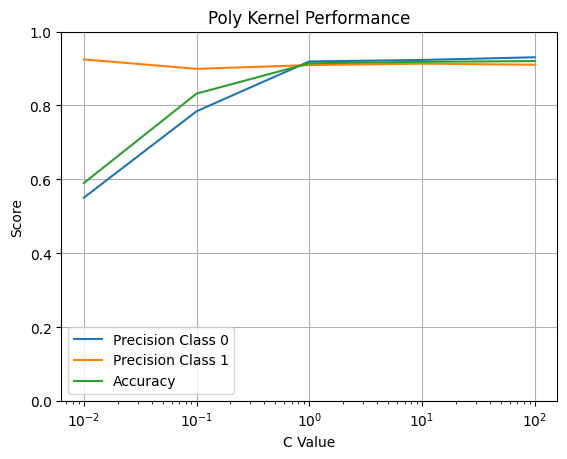

In [26]:
def plot_kernel_results(results, c_values, kernel_name):
    """
    Creates plots comparing the three values(Precision class 1, Precision class 0, and Overall accuracy) vs different C values, for each of the three kernals

    Parameters:
    - results: This is one of the outputs of the previous function. linear, rbf, or poly
    - c_values: The list of C values the model was trained with
    - kernal_name: What the Kernal name is(Should be same as the results input but in quotations)

    Returns:
    - Returns a plot with the three values on the y axis and the C values on the X axis
    
    """
    
    #Create plots with each of the values we tracked above
    results = np.array(results)
    plt.plot(c_values, results[:, 0], label="Precision Class 0")
    plt.plot(c_values, results[:, 1], label="Precision Class 1")
    plt.plot(c_values, results[:, 2], label="Accuracy")
    #Labeling the plots
    plt.title(f"{kernel_name} Kernel Performance")
    plt.xlabel("C Value")
    plt.ylabel("Score")
    plt.xscale("log")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

c_values = [0.01, 0.1, 1, 10, 100]
plot_kernel_results(linear, c_values, "Linear")
plot_kernel_results(rbf, c_values, "RBF")
plot_kernel_results(poly, c_values, "Poly")


              precision    recall  f1-score   support

      Normal       0.94      0.92      0.93       250
   Pneumonia       0.92      0.94      0.93       250

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



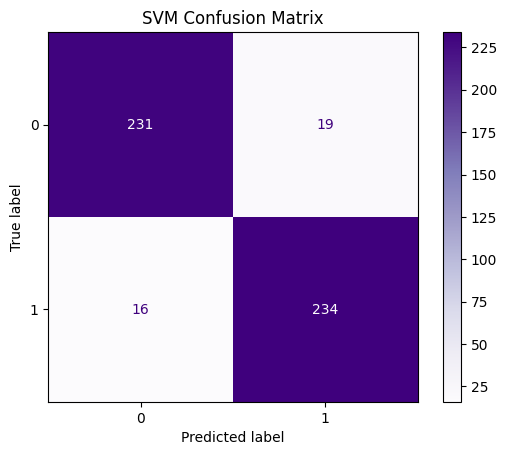

In [60]:
#train an SVM
clf = OneVsRestClassifier(SVC(kernel='rbf', C=10, class_weight='balanced'))
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=categories))

#plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_pca, y_test, cmap='Purples')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("SVM Confusion Matrix")
plt.show()
